In [12]:
import os

from scipy.io import loadmat
import cv2
import numpy as np

from math import sin, cos

import matplotlib.pyplot as plt
%matplotlib inline

In [53]:
def draw_axis(img, yaw, pitch, roll, tdx=None, tdy=None, size = 100):

    if tdx != None and tdy != None:
        tdx = tdx
        tdy = tdy
    else:
        height, width = img.shape[:2]
        tdx = width / 2
        tdy = height / 2

    # X-Axis pointing to right. drawn in blue
    x1 = size * (cos(yaw) * cos(roll)) + tdx
    y1 = size * (cos(pitch) * sin(roll) + cos(roll) * sin(pitch) * sin(yaw)) + tdy

    # Y-Axis | drawn in green
    #        v
    x2 = size * (-cos(yaw) * sin(roll)) + tdx
    y2 = size * (cos(pitch) * cos(roll) - sin(pitch) * sin(yaw) * sin(roll)) + tdy

    # Z-Axis (out of the screen) drawn in red
    x3 = size * (sin(yaw)) + tdx
    y3 = size * (-cos(yaw) * sin(pitch)) + tdy

    cv2.line(img, (int(tdx), int(tdy)), (int(x1),int(y1)),(0,0,255),3)
    cv2.line(img, (int(tdx), int(tdy)), (int(x2),int(y2)),(0,255,0),3)
    cv2.line(img, (int(tdx), int(tdy)), (int(x3),int(y3)),(255,0,0),3)

    return img

In [89]:
def draw_axis_over_img(img_name):
    image = cv2.imread(f"../../data/300W-LP/300W_LP/AFW/{img_name}.jpg")
    image_data = loadmat(f"../../data/300W-LP/300W_LP/AFW/{img_name}.mat")
    
    p, y, r = image_data['Pose_Para'][0,:3]
    y = -y
    
    print(f"converted angles:")
    print(f"pitch: {p*(180/np.pi)}")
    print(f"roll: {r*(180/np.pi)}")
    print(f"yaw: {y*(180/np.pi)}")
    
    
    plotted_image = draw_axis(image, y, p, r, tdx=200, tdy=200, size = 100)
    plt.imshow(plotted_image)
    plt.show()

converted angles:
pitch: -6.1849945599745375
roll: 11.18050569957583
yaw: 12.858785631485514


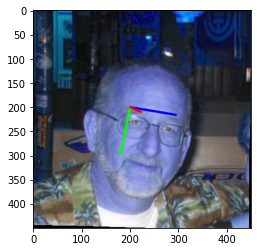

In [90]:
draw_axis_over_img("AFW_261068_1_1")

converted angles:
pitch: -8.197683541855806
roll: 9.40307703412695
yaw: 32.858786757218645


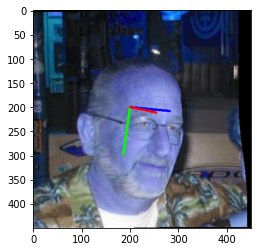

In [91]:
draw_axis_over_img("AFW_261068_1_5")

converted angles:
pitch: -19.86501951226076
roll: -9.648687221586023
yaw: -86.86726110957095


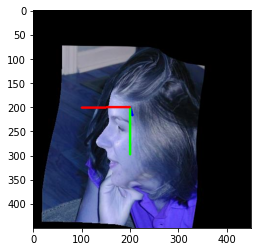

In [92]:
draw_axis_over_img("AFW_134212_1_12")

converted angles:
pitch: -19.44305042533737
roll: -11.721906620552414
yaw: -31.867261855786236


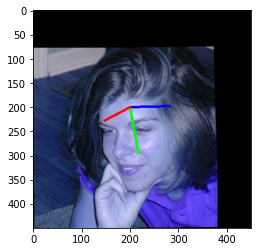

In [93]:
draw_axis_over_img("AFW_134212_1_1")

converted angles:
pitch: -8.126044248972482
roll: -21.770729375606233
yaw: -5.544546077635836


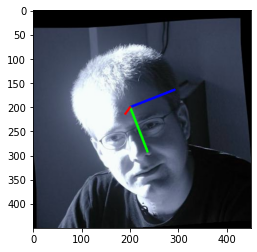

In [94]:
draw_axis_over_img("AFW_3989161_1_1")

converted angles:
pitch: -38.70036751657458
roll: -2.061708182337393
yaw: 7.235629199144708


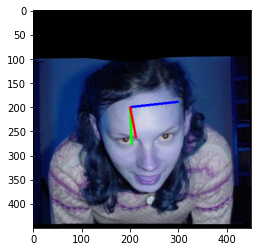

In [95]:
draw_axis_over_img("AFW_4821642_1_1")

converted angles:
pitch: -3.2253337871734384
roll: -12.685010251074756
yaw: 14.84187300039077


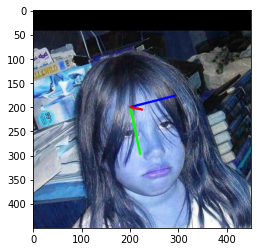

In [96]:
draw_axis_over_img("AFW_899545263_1_0")